In [20]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from huggingface_hub import PyTorchModelHubMixin

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("PyTorch version:", torch.__version__)


Using device: cpu
PyTorch version: 2.13.0+cpu


In [21]:
class Generator(nn.Module, PyTorchModelHubMixin):
    """DCGAN-style generator, compatible with nateraw/cryptopunks-gan."""

    def __init__(self, num_channels=3, latent_dim=100, hidden_size=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.model = nn.Sequential(
            # (latent_dim, 1, 1) -> (hidden_size*4, 4, 4)
            nn.ConvTranspose2d(latent_dim, hidden_size * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(hidden_size * 4),
            nn.ReLU(True),
            # -> (hidden_size*2, 8, 8)
            nn.ConvTranspose2d(hidden_size * 4, hidden_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(hidden_size * 2),
            nn.ReLU(True),
            # -> (hidden_size, 16, 16)
            nn.ConvTranspose2d(hidden_size * 2, hidden_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(hidden_size),
            nn.ReLU(True),
            # -> (hidden_size, 32, 32)
            nn.ConvTranspose2d(hidden_size, hidden_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(hidden_size),
            nn.ReLU(True),
            # -> (num_channels, 64, 64)
            nn.ConvTranspose2d(hidden_size, num_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        if z.dim() == 2:
            z = z.view(z.size(0), z.size(1), 1, 1)
        return self.model(z)

print("Generator class defined.")


Generator class defined.


In [22]:
MODEL_REPO = "nateraw/cryptopunks-gan"

try:
    generator = Generator.from_pretrained(MODEL_REPO)
    USING_PRETRAINED = True
    print(f"Loaded pretrained weights from '{MODEL_REPO}'")
except Exception as e:
    print(f"Could not reach the Hugging Face Hub ({type(e).__name__}).")
    print("Falling back to a randomly-initialized Generator with the same "
          "architecture, so the pipeline below still runs end-to-end.")
    generator = Generator(num_channels=3, latent_dim=100, hidden_size=64)
    USING_PRETRAINED = False

generator.to(device)

# Pretrained weights expect eval() mode (uses the learned BatchNorm running
# statistics). The untrained fallback network has no meaningful running
# statistics yet, so we keep it in train() mode purely so BatchNorm uses
# per-batch statistics -- this just makes the random fallback output more
# visually varied for the demo; it does not affect the pretrained branch.
if USING_PRETRAINED:
    generator.eval()
else:
    generator.train()

print("USING_PRETRAINED =", USING_PRETRAINED)
print(generator)


Could not reach the Hugging Face Hub (RemoteEntryNotFoundError).
Falling back to a randomly-initialized Generator with the same architecture, so the pipeline below still runs end-to-end.
USING_PRETRAINED = False
Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=Fa

In [23]:
LATENT_DIM = generator.latent_dim
BATCH_SIZE = 8

def sample_noise(n, latent_dim=LATENT_DIM, seed=None):
    g = torch.Generator(device="cpu")
    if seed is not None:
        g.manual_seed(seed)
    z = torch.randn(n, latent_dim, 1, 1, generator=g)
    return z.to(device)

z = sample_noise(BATCH_SIZE, seed=0)
print("Noise tensor shape:", z.shape)
print("First noise vector, first 10 values:\n", z[0, :10, 0, 0].cpu().numpy())


Noise tensor shape: torch.Size([8, 100, 1, 1])
First noise vector, first 10 values:
 [-1.1258398  -1.1523602  -0.25057858 -0.4338788   0.84871036  0.69200915
 -0.31601277 -2.1152194   0.32227492 -1.2633348 ]


In [24]:
with torch.no_grad():
    fake_images = generator(z)

print("Generated image batch shape:", fake_images.shape)  # (N, C, H, W)
print("Pixel value range:", fake_images.min().item(), "to", fake_images.max().item())


Generated image batch shape: torch.Size([8, 3, 64, 64])
Pixel value range: -0.9994983077049255 to 0.9979163408279419


In [25]:
def to_displayable(img_tensor):
    """(C,H,W) tensor in [-1,1] -> (H,W,C) numpy array in [0,1]"""
    img = img_tensor.detach().cpu().numpy()
    img = (img + 1) / 2.0          # [-1,1] -> [0,1]
    img = np.clip(img, 0, 1)
    img = np.transpose(img, (1, 2, 0))  # C,H,W -> H,W,C
    return img

def show_batch(images, title, ncols=4):
    n = images.shape[0]
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 2.2 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(to_displayable(images[i]))
            ax.set_title(f"#{i}", fontsize=9)
        ax.axis("off")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

print("Helpers ready.")


Helpers ready.


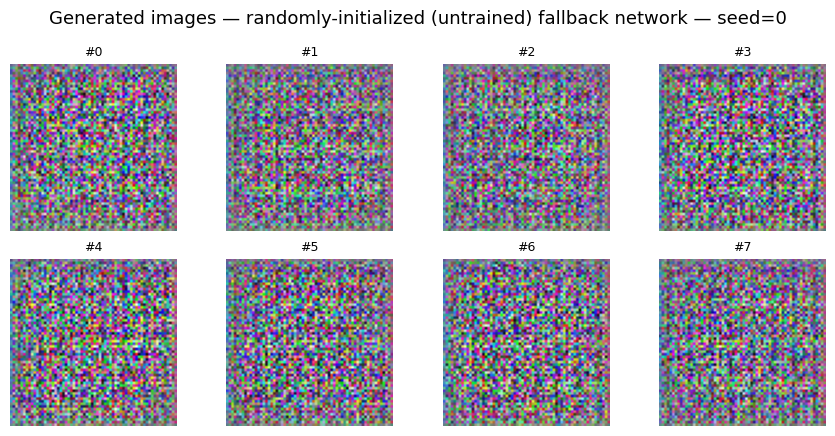

In [26]:
status = "pretrained CryptoPunks-GAN" if USING_PRETRAINED else "randomly-initialized (untrained) fallback network"
show_batch(fake_images, title=f"Generated images — {status} — seed=0")


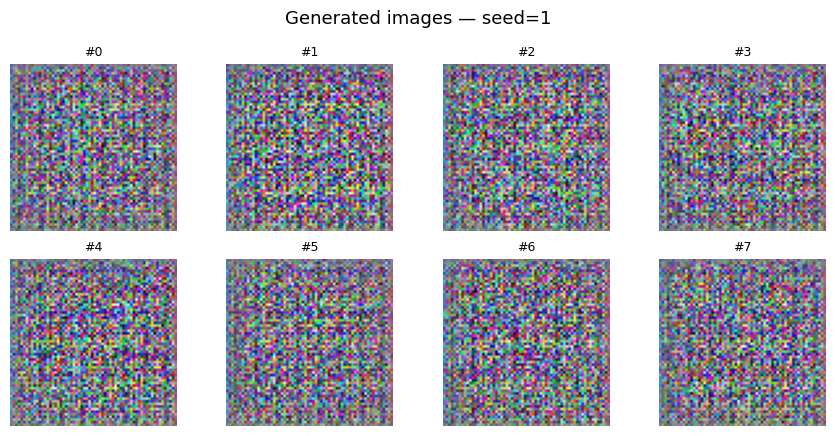

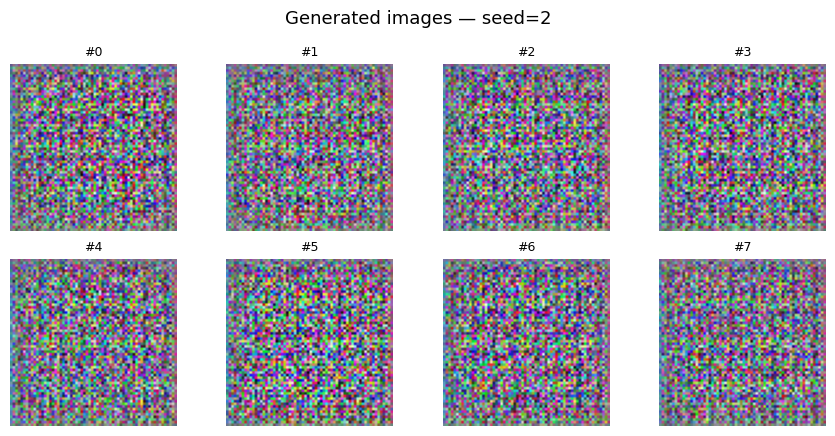

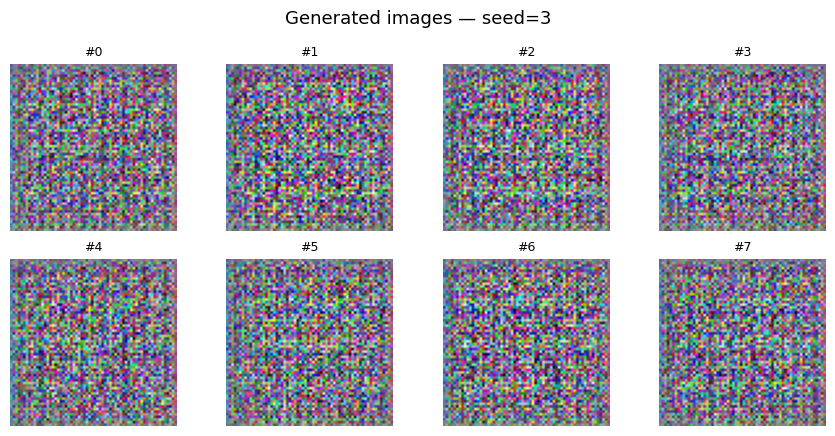

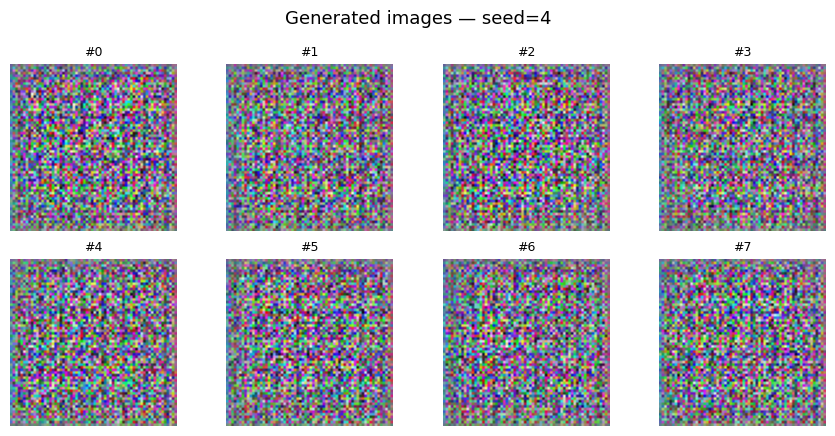

In [27]:
seeds = [1, 2, 3, 4]

for s in seeds:
    z_s = sample_noise(BATCH_SIZE, seed=s)
    with torch.no_grad():
        imgs_s = generator(z_s)
    show_batch(imgs_s, title=f"Generated images — seed={s}")


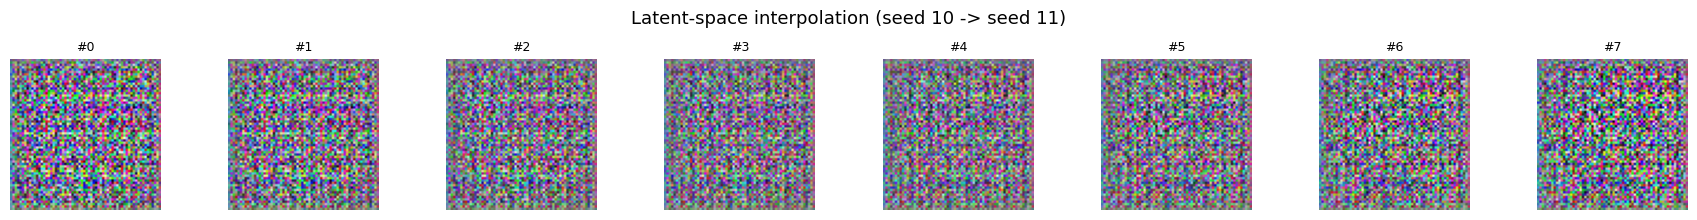

In [28]:
def interpolate(z_start, z_end, steps=8):
    alphas = torch.linspace(0, 1, steps).view(-1, 1, 1, 1).to(device)
    return z_start.unsqueeze(0) * (1 - alphas) + z_end.unsqueeze(0) * alphas

z_a = sample_noise(1, seed=10)[0]
z_b = sample_noise(1, seed=11)[0]

z_path = interpolate(z_a, z_b, steps=8)
with torch.no_grad():
    interp_images = generator(z_path)

show_batch(interp_images, title="Latent-space interpolation (seed 10 -> seed 11)", ncols=8)
